# 02 - GAT Training
Graph Attention Network na datasecie Cora - porównanie z GCN przy różnych progach etykiet.

In [1]:
import os, json
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from torch_geometric.datasets import Planetoid
from torch_geometric.nn import GATConv

os.makedirs('../models', exist_ok=True)
os.makedirs('../results', exist_ok=True)

dataset = Planetoid(root='../data/Cora', name='Cora')
data = dataset[0]
original_train_mask = data.train_mask.clone()

print(f'Węzły:    {data.num_nodes}')
print(f'Krawędzie: {data.num_edges}')
print(f'Klasy:    {dataset.num_classes}')

Węzły:    2708
Krawędzie: 10556
Klasy:    7


## Wczytanie wyników GCN
Zamiast trenować GCN od nowa, wczytujemy zapisane wyniki z 01_gcn.ipynb.

In [2]:
with open('../models/gcn_results.json') as f:
    gcn_raw = json.load(f)

gcn_results = {float(k): v for k, v in gcn_raw.items()}

ratios = [0.05, 0.10, 0.20]
seeds  = [42, 123, 456, 789, 1000]
labels = ['5%', '10%', '20%']

print('Wyniki GCN wczytane:')
for ratio, accs in gcn_results.items():
    print(f'  {ratio:.0%}: {np.mean(accs):.4f} ± {np.std(accs):.4f}')

Wyniki GCN wczytane:
  5%: 0.7922 ± 0.0147
  10%: 0.8152 ± 0.0143
  20%: 0.8274 ± 0.0147


## Funkcja create_split
Identyczna jak w 01_gcn

In [3]:
def create_split(data, label_ratio, seed=42):
    torch.manual_seed(seed)

    available_indices = (~data.test_mask).nonzero(as_tuple=True)[0]

    train_size = int(data.num_nodes * label_ratio)
    shuffled = available_indices[torch.randperm(len(available_indices))]

    train_mask = torch.zeros(data.num_nodes, dtype=torch.bool)
    train_mask[shuffled[:train_size]] = True

    return train_mask

def train(model, optimizer):
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = F.nll_loss(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

def test(model):
    model.eval()
    with torch.no_grad():
        out = model(data.x, data.edge_index)
    pred = out.argmax(dim=1)
    acc = (pred[data.test_mask] == data.y[data.test_mask]).float().mean()
    return acc.item()

Funkcje zdefiniowane


## Architektura GAT
Veličković et al. (2018) - mechanizm attention pozwala różnie ważyć wpływ sąsiadów
Nie wszyscy sąsiedzi są równie ważni - selektywna agregacja informacji

In [4]:
class GAT(torch.nn.Module):
    def __init__(self, in_channels, 
                 hidden_channels, 
                 out_channels, heads=8):
        super().__init__()
        self.conv1 = GATConv(in_channels, 
                             hidden_channels, 
                             heads=heads, 
                             dropout=0.6)
        self.conv2 = GATConv(hidden_channels * heads, 
                             out_channels, 
                             heads=1, 
                             dropout=0.6)

    def forward(self, x, edge_index):
        x = F.dropout(x, p=0.6, training=self.training)
        x = self.conv1(x, edge_index)
        x = F.elu(x)
        x = F.dropout(x, p=0.6, training=self.training)
        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)

## Baseline - standardowy split Planetoid
Odtworzenie wyników z oryginalnego papieru Veličković et al. (2018): 83.0% na Corze.

In [5]:
data.train_mask = original_train_mask

baseline_model = GAT(dataset.num_features, 8, dataset.num_classes)
baseline_optimizer = torch.optim.Adam(
    baseline_model.parameters(), lr=0.005, weight_decay=5e-4)

for epoch in range(200):
    loss = train(baseline_model, baseline_optimizer)
    if epoch % 20 == 0:
        acc = test(baseline_model)
        print(f'Epoch {epoch:3d}: Loss={loss:.4f}, Acc={acc:.4f}')

baseline_acc = test(baseline_model)
print(f'\nBaseline GAT (paper split): {baseline_acc:.4f}')
print(f'Paper (Veličković 2018): 0.830')

Epoch   0: Loss=1.9692, Acc=0.3880
Epoch  20: Loss=0.8498, Acc=0.8190
Epoch  40: Loss=0.6689, Acc=0.8200
Epoch  60: Loss=0.5485, Acc=0.8140
Epoch  80: Loss=0.4670, Acc=0.8110
Epoch 100: Loss=0.4011, Acc=0.8120
Epoch 120: Loss=0.4861, Acc=0.8050
Epoch 140: Loss=0.4211, Acc=0.8000
Epoch 160: Loss=0.4238, Acc=0.8000
Epoch 180: Loss=0.4348, Acc=0.7960

Baseline GAT (paper split): 0.8060
Paper (Veličković 2018):    ~0.830


## Eksperymenty - accuracy vs liczba etykiet

In [6]:
gat_results = defaultdict(list)
best_acc = 0

for ratio in ratios:
    for seed in seeds:
        data.train_mask = create_split(data, ratio, seed)

        model = GAT(dataset.num_features, 8, dataset.num_classes)
        optimizer = torch.optim.Adam(
            model.parameters(), lr=0.005, weight_decay=5e-4)

        for epoch in range(200):
            train(model, optimizer)

        acc = test(model)
        gat_results[ratio].append(acc)
        print(f'GAT | Ratio: {ratio:.0%}, Seed: {seed}, Acc: {acc:.4f}')

        if acc > best_acc:
            best_acc = acc
            torch.save(model.state_dict(), '../models/gat_best.pt')

# przywróć oryginalny split
data.train_mask = original_train_mask

print('\n--- Podsumowanie GAT ---')
for ratio, accs in gat_results.items():
    print(f'{ratio:.0%}: {np.mean(accs):.4f} ± {np.std(accs):.4f}')
print(f'Najlepszy model: {best_acc:.4f}')

GAT | Ratio: 5%, Seed: 42, Acc: 0.8070
GAT | Ratio: 5%, Seed: 123, Acc: 0.8130
GAT | Ratio: 5%, Seed: 456, Acc: 0.8000
GAT | Ratio: 5%, Seed: 789, Acc: 0.8170
GAT | Ratio: 5%, Seed: 1000, Acc: 0.7920
GAT | Ratio: 10%, Seed: 42, Acc: 0.8340
GAT | Ratio: 10%, Seed: 123, Acc: 0.8090
GAT | Ratio: 10%, Seed: 456, Acc: 0.8200
GAT | Ratio: 10%, Seed: 789, Acc: 0.8260
GAT | Ratio: 10%, Seed: 1000, Acc: 0.8150
GAT | Ratio: 20%, Seed: 42, Acc: 0.8480
GAT | Ratio: 20%, Seed: 123, Acc: 0.8360
GAT | Ratio: 20%, Seed: 456, Acc: 0.8560
GAT | Ratio: 20%, Seed: 789, Acc: 0.8300
GAT | Ratio: 20%, Seed: 1000, Acc: 0.8540

--- Podsumowanie GAT ---
5%: 0.8058 ± 0.0090
10%: 0.8208 ± 0.0087
20%: 0.8448 ± 0.0102
Najlepszy model: 0.8560


# GCC vs GAT    

In [11]:
all_results = {'GCN': gcn_results, 'GAT': dict(gat_results)}

print('--- GCN vs GAT ---')
print(f'{"Model":<10} {"5%":>12} {"10%":>12} {"20%":>12}')
print('-' * 50)
for name, res in all_results.items():
    row = f'{name:<10}'
    for ratio in ratios:
        accs = res[ratio]
        row += f'  {np.mean(accs):.4f}±{np.std(accs):.4f}'
    print(row)

print('\n--- Różnica GAT - GCN ---')
for ratio in ratios:
    diff = np.mean(gat_results[ratio]) - np.mean(gcn_results[ratio])
    print(f'{ratio:.0%}: +{diff:.4f}')

--- GCN vs GAT ---
Model                5%          10%          20%
--------------------------------------------------
GCN         0.7922±0.0147  0.8152±0.0143  0.8274±0.0147
GAT         0.8058±0.0090  0.8208±0.0087  0.8448±0.0102

--- Różnica GAT - GCN ---
5%: +0.0136
10%: +0.0056
20%: +0.0174


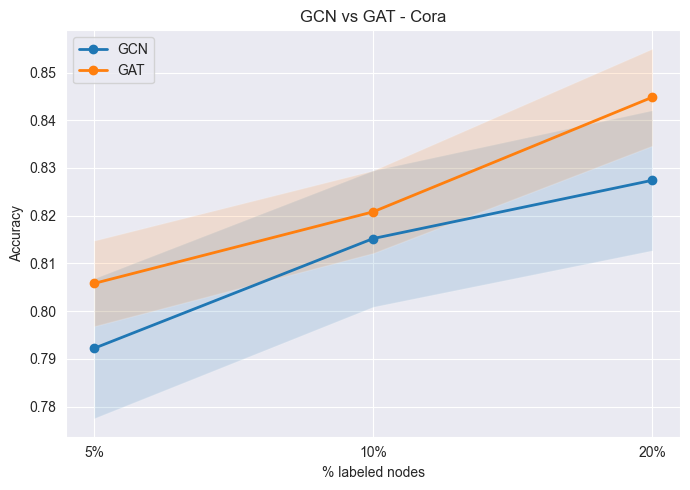

Wykres zapisany: ../results/gcn_vs_gat.png


In [16]:
plt.figure(figsize=(7, 5))

for name, res in all_results.items():
    means = [np.mean(res[r]) for r in ratios]
    stds  = [np.std(res[r])  for r in ratios]
    plt.plot(labels, means, marker='o', linewidth=2, label=name)
    plt.fill_between(labels,
                     [m - s for m, s in zip(means, stds)],
                     [m + s for m, s in zip(means, stds)],
                     alpha=0.15)

plt.xlabel('% labeled nodes')
plt.ylabel('Accuracy')
plt.title('GCN vs GAT - Cora')
plt.legend()
plt.tight_layout()
plt.savefig('../results/gcn_vs_gat.png')
plt.show()
print('Wykres zapisany: ../results/gcn_vs_gat.png')

## Zapis wyników

In [9]:
gat_serializable = {str(k): v for k, v in gat_results.items()}
with open('../models/gat_results.json', 'w') as f:
    json.dump(gat_serializable, f, indent=2)

all_serializable = {
    name: {str(k): v for k, v in res.items()}
    for name, res in all_results.items()
}
with open('../models/all_results.json', 'w') as f:
    json.dump(all_serializable, f, indent=2)

print('Zapisano:')
print('../models/gat_results.json')
print('../models/gat_best.pt')
print('../models/all_results.json')
print('../results/gcn_vs_gat.png')

Zapisano:
  ../models/gat_results.json
  ../models/gat_best.pt
  ../models/all_results.json
  ../results/gcn_vs_gat.png
